## Loan Master Dataset 

## IMPORT LIBRARIES

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

## Data Understanding

In [54]:

# LOAD DATA
# ==============================
df = pd.read_csv(r"C:\Users\WINDOWS 11\Desktop\year5\data for thesis\Data\Loan Master Listing.csv")

print("✅ Data Loaded")
display(df.head())

✅ Data Loaded


,ACC,CID,PRINCIPALAMT,BALAMT,TERM_Extend,INTRATE,AcrIntAmt,LoanAge_Current,PrType,AccountType,...,Principal_Fequency,Restructure,OrigTerm,GracePeriod,NumInstPaid,NumInstNotPaid,NumInstNotDue,Reloan,AgeOfReloan,PAYMENT_MODE
0,BMC892008137037,BMC008137,"1,600.00",754.74,72,18.0,56.88,166,ENL,I,...,1,N,72,0,38,6,28,Yes,46,Declining
1,BMC892009406033,BMC009406,"5,000.00","2,278.00",60,18.0,554.72,719,ENL,I,...,1,Y,36,3,26,24,10,Yes,0,Balloon
2,BMCLAFL20145501,BMC006164,"5,000.00",416.63,36,18.0,9.17,19,AFL,I,...,1,N,36,0,33,1,2,TOPUP,0,Declining
3,BMCLAFL20161896,BMC0032927,"4,000.00",777.81,36,18.0,5.07,0,AFL,I,...,1,N,36,0,29,0,7,No,0,Declining
4,BMCLAFL20178861,BMC010169,"4,000.00","2,113.75",36,18.0,217.66,257,AFL,I,...,1,N,36,0,16,9,11,No,0,Declining


In [55]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': df.nunique().values
})
display(summary)

,Column,Data Type,Unique Values
0,ACC,object,4645
1,CID,object,4617
2,PRINCIPALAMT,object,146
3,BALAMT,object,3172
4,TERM_Extend,int64,59
5,INTRATE,float64,13
6,AcrIntAmt,object,2559
7,LoanAge_Current,int64,274
8,PrType,object,25
9,AccountType,object,3


## Data Cleaning

Clean Column Names

In [56]:
# CLEAN COLUMN NAMES

df.columns = df.columns.str.strip()

print("\n✅ Column Names Cleaned")
print(df.columns.tolist())


✅ Column Names Cleaned
['ACC', 'CID', 'PRINCIPALAMT', 'BALAMT', 'TERM_Extend', 'INTRATE', 'AcrIntAmt', 'LoanAge_Current', 'PrType', 'AccountType', 'Sector', 'LOANCYCLE', 'PARCategory', 'Principal_Fequency', 'Restructure', 'OrigTerm', 'GracePeriod', 'NumInstPaid', 'NumInstNotPaid', 'NumInstNotDue', 'Reloan', 'AgeOfReloan', 'PAYMENT_MODE']


In [57]:
# CHECK MISSING VALUES

missing = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Missing (%)': (df.isnull().sum().values / len(df)) * 100
})

print("\n=== MISSING VALUES CHECK ===")
display(missing)


=== MISSING VALUES CHECK ===


,Column,Missing Values,Missing (%)
0,ACC,0,0.0
1,CID,0,0.0
2,PRINCIPALAMT,0,0.0
3,BALAMT,0,0.0
4,TERM_Extend,0,0.0
5,INTRATE,0,0.0
6,AcrIntAmt,0,0.0
7,LoanAge_Current,0,0.0
8,PrType,0,0.0
9,AccountType,0,0.0


In [58]:
# REMOVE DUPLICATES

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"\n✅ Removed {before - after} duplicate rows")


✅ Removed 0 duplicate rows


In [59]:
# DROP UNUSED COLUMNS

df = df.drop(columns=[
    'ACC',
    'CID'
])

print("\n✅ Dropped ACC and CID")




✅ Dropped ACC and CID


## Feature engineering

In [60]:
def risk_level(par):
    if par == '0 days':
        return 1
    elif par == '1-29 days':
        return 2
    elif par == '30-89 days':
        return 3
    elif par == '90+ days':
        return 4
    else:
        return None

df['Risk_Level'] = df['PARCategory'].apply(risk_level)

In [61]:
df['Risk_Binary'] = (df['Risk_Level'] >= 3).astype(int)

old

In [62]:
# CREATE RISK LEVEL (TARGET)

def risk_level(par):
    if par == '0 days':
        return 1
    elif par == '1-29 days':
        return 2
    elif par == '30-89 days':
        return 3
    elif par == '90+ days':
        return 4
    else:
        return None

df['Risk_Level'] = df['PARCategory'].apply(risk_level)

# Show mapping table
risk_table = pd.DataFrame({
    'PARCategory': ['0 days', '1-29 days', '30-89 days', '90+ days'],
    'Risk_Level': [1, 2, 3, 4],
    'Meaning': ['Normal', 'Slight Delay', 'Risk', 'High Risk']
})

print("\n=== RISK LEVEL MAPPING ===")
display(risk_table)




=== RISK LEVEL MAPPING ===


,PARCategory,Risk_Level,Meaning
0,0 days,1,Normal
1,1-29 days,2,Slight Delay
2,30-89 days,3,Risk
3,90+ days,4,High Risk


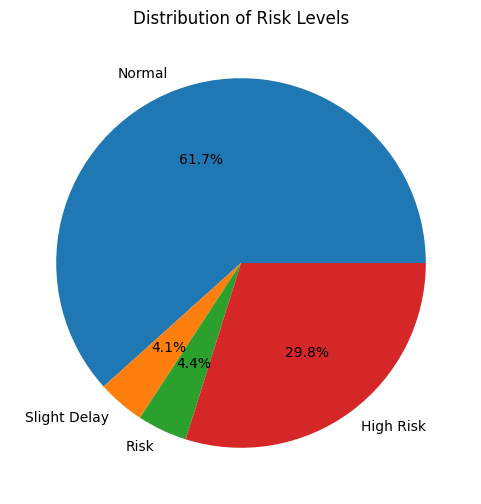

In [63]:
risk_counts = df['Risk_Level'].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(
    risk_counts,
    labels=['Normal','Slight Delay','Risk','High Risk'],
    autopct='%1.1f%%'
)

plt.title("Distribution of Risk Levels")
plt.show()

## Data transformation

In [64]:


num_cols = ['PRINCIPALAMT', 'BALAMT', 'AcrIntAmt']

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [65]:
df['AcrIntAmt'] = df['AcrIntAmt'].fillna(0)

LOG TRANSFORMATION

In [66]:


skewed_cols = ['PRINCIPALAMT', 'BALAMT', 'AcrIntAmt']

df_before = df.copy()  # for visualization

for col in skewed_cols:
    df[col] = np.log1p(df[col])

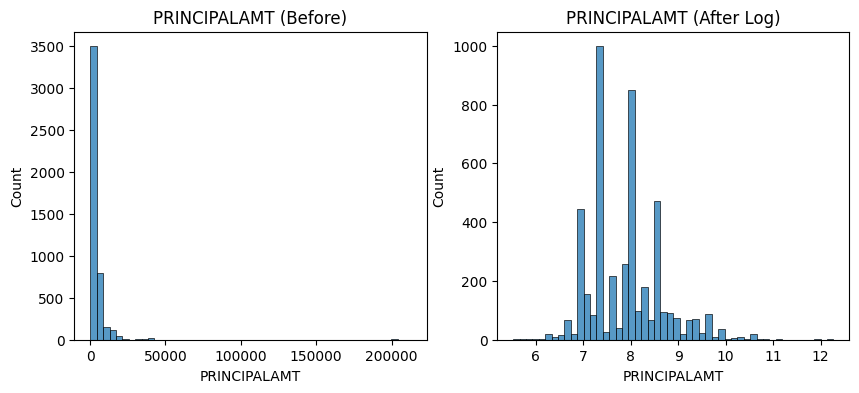

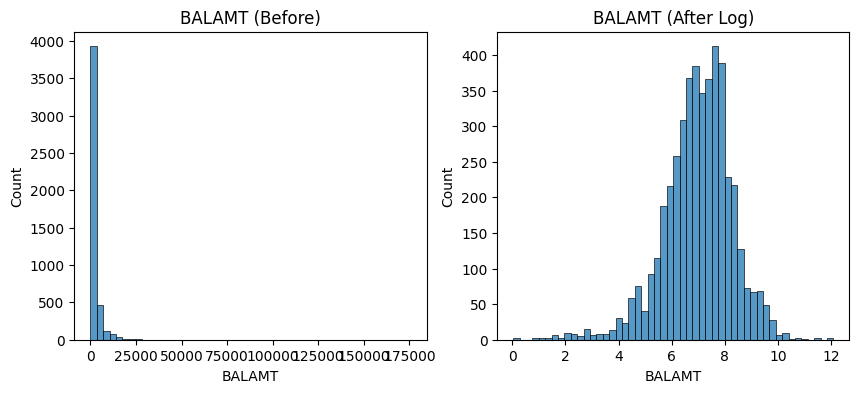

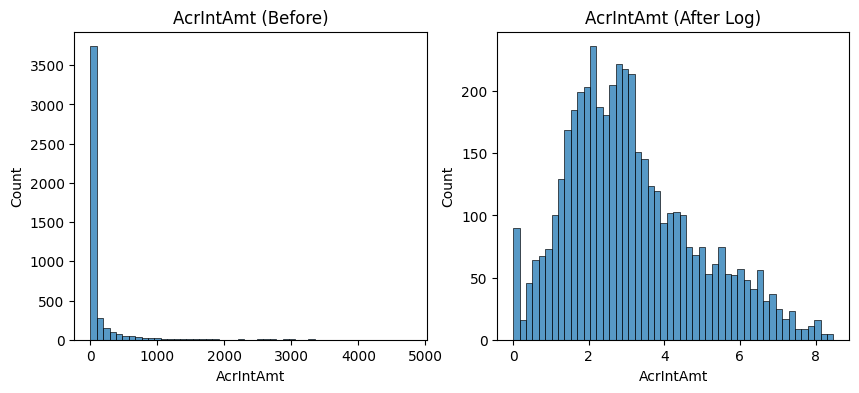

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in skewed_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df_before[col], bins=50)
    plt.title(f"{col} (Before)")

    plt.subplot(1,2,2)
    sns.histplot(df[col], bins=50)
    plt.title(f"{col} (After Log)")

    plt.show()
    

## Encode Categorical Variables

In [68]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['PrType', 'AccountType', 'Sector', 'Restructure', 'Reloan', 'PAYMENT_MODE']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))

df = df.drop(columns=cat_cols)
df = pd.concat([df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

Define X and y

In [69]:
df = df.drop(columns=['PARCategory'], errors='ignore')

In [70]:
df['Risk_Binary'] = (df['Risk_Level'] >= 3).astype(int)

In [71]:
X = df.drop(columns=['Risk_Level', 'Risk_Binary'], errors='ignore')
y = df['Risk_Binary']

Feature Count After Encoding

In [72]:
print("Total Features After Encoding:", df.shape[1])

Total Features After Encoding: 61


## FEATURE SELECTION

Feature Importance Visualization

SCALING

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## SPLIT DATA

In [74]:
df_model = df.drop(columns=['ACC', 'CID', 'PARCategory'], errors='ignore')

In [75]:
X = df_model.drop(columns=['Risk_Level'])
y = df_model['Risk_Level']

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

## DATA NORMALIZATION

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## FEATURE RELATIONSHIP ANALYSIS (BEFORE PCA)

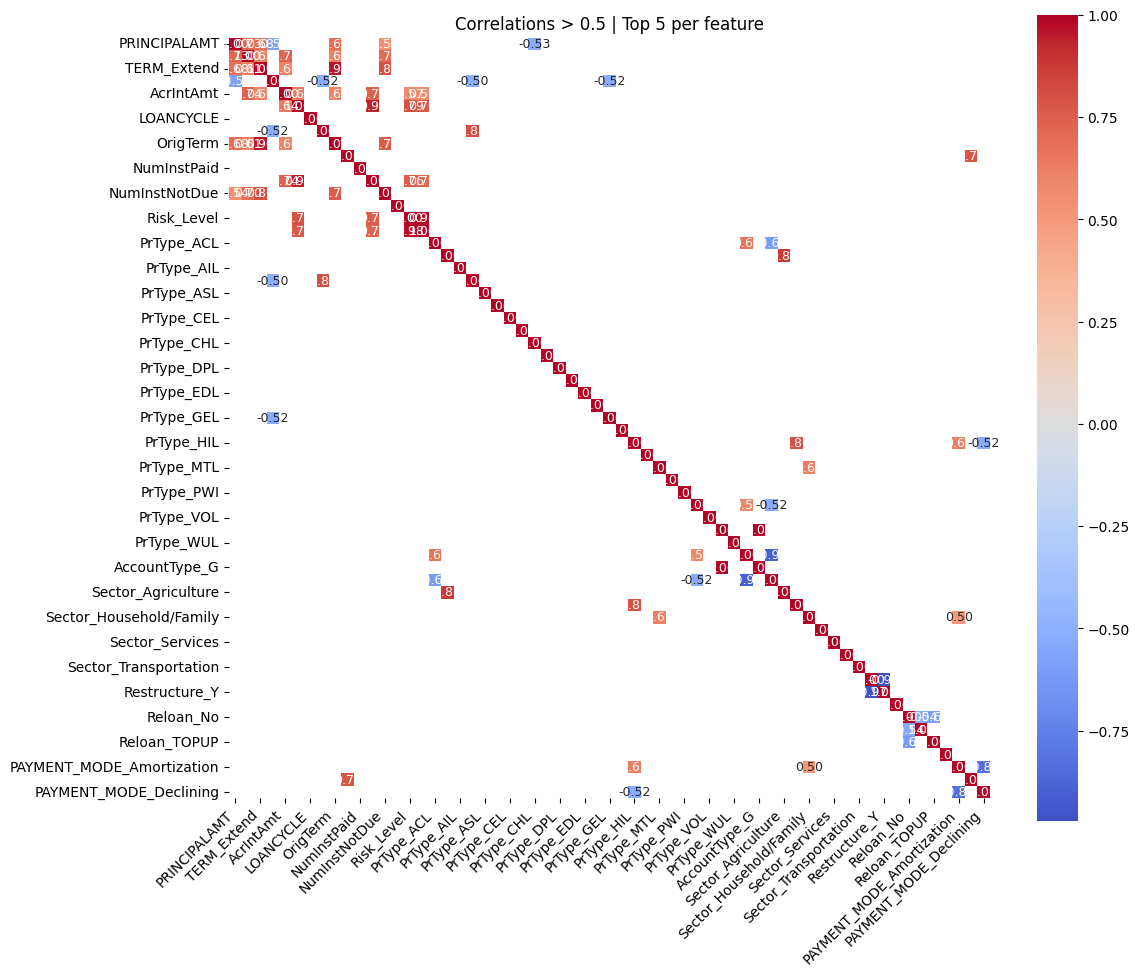

,PRINCIPALAMT,BALAMT,TERM_Extend,INTRATE,AcrIntAmt,LoanAge_Current,LOANCYCLE,Principal_Fequency,OrigTerm,GracePeriod,...,Restructure_N,Restructure_Y,Restructure_YES_BY_RLO,Reloan_No,Reloan_RELOAN,Reloan_TOPUP,Reloan_Yes,PAYMENT_MODE_Amortization,PAYMENT_MODE_Balloon,PAYMENT_MODE_Declining
PRINCIPALAMT,1.000000,0.728775,0.679710,-0.578991,NaN,NaN,NaN,NaN,0.684981,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BALAMT,0.728775,1.000000,0.614339,NaN,0.736197,NaN,NaN,NaN,0.611207,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TERM_Extend,0.679710,0.614339,1.000000,NaN,0.601218,NaN,NaN,NaN,0.957121,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INTRATE,-0.578991,NaN,NaN,1.000000,NaN,NaN,NaN,-0.517042,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AcrIntAmt,NaN,0.736197,0.601218,NaN,1.000000,0.638032,NaN,NaN,0.595646,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Reloan_TOPUP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.615317,NaN,1.0,NaN,NaN,NaN,NaN
Reloan_Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
PAYMENT_MODE_Amortization,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,-0.825778
PAYMENT_MODE_Balloon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.781007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [79]:
def smart_correlation_heatmap(df, threshold=0.5, top_per_feature=5):
    """Smart correlation heatmap that shows only strong correlations"""
    corr = df.corr(numeric_only=True)
    
    # Method 1: Apply threshold
    mask_threshold = np.abs(corr) < threshold
    corr_filtered = corr.copy()
    corr_filtered[mask_threshold] = np.nan
    
    # Method 2: Keep only top N per feature
    for col in corr.columns:
        col_corr = corr[col].abs()
        top_indices = col_corr.nlargest(top_per_feature + 1).index
        mask = ~corr.index.isin(top_indices)
        corr_filtered.loc[mask, col] = np.nan
    
    # Clean up rows/cols with all NaN
    corr_filtered = corr_filtered.dropna(how='all').dropna(axis=1, how='all')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_filtered, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, annot_kws={'size': 9})
    plt.title(f"Correlations > {threshold} | Top {top_per_feature} per feature")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return corr_filtered

# Use it
smart_correlation_heatmap(df, threshold=0.5, top_per_feature=5)

## PCA (DIMENSIONALITY REDUCTION)

In [80]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

## PCA Explained Variance

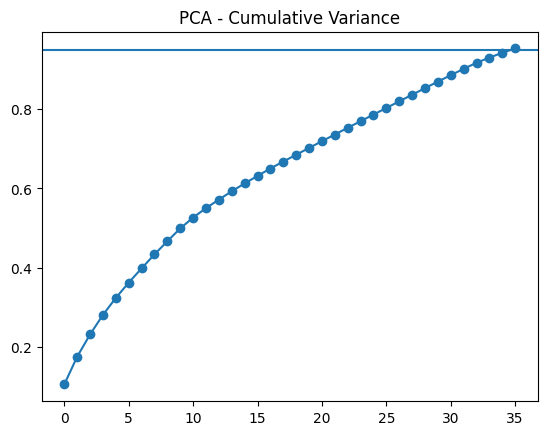

In [81]:
import numpy as np

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(cum_var, marker='o')
plt.axhline(y=0.95)
plt.title("PCA - Cumulative Variance")
plt.show()

Scree Plot

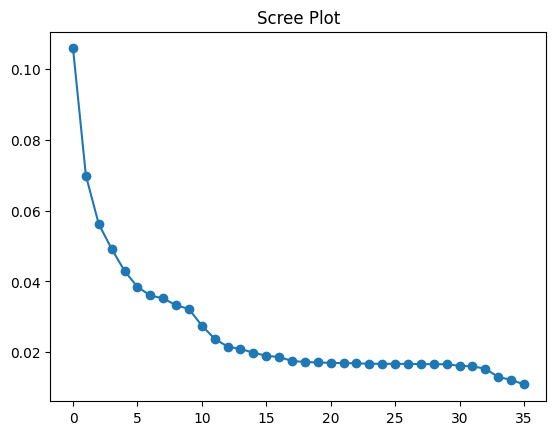

In [82]:
plt.figure()
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.show()

PCA 2D Projection

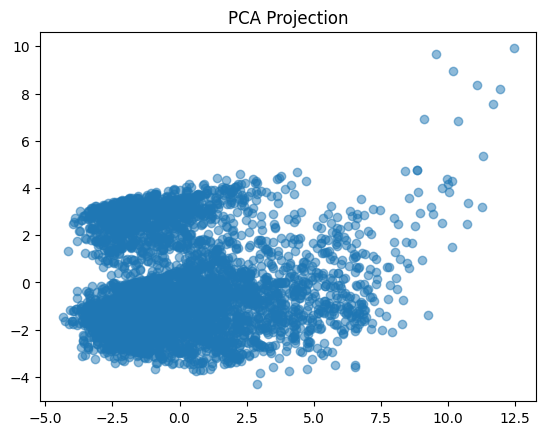

In [83]:
X_pca_2D = X_pca[:, :2]

plt.figure()
plt.scatter(X_pca_2D[:, 0], X_pca_2D[:, 1], alpha=0.5)
plt.title("PCA Projection")
plt.show()

## PCA + Risk Level

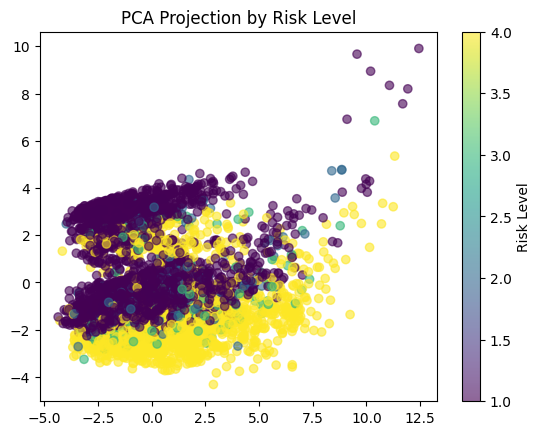

In [84]:
plt.figure()

plt.scatter(
    X_pca_2D[:, 0],
    X_pca_2D[:, 1],
    c=y,
    alpha=0.6
)

plt.title("PCA Projection by Risk Level")
plt.colorbar(label='Risk Level')

plt.show()

Check Variance

In [85]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Kept:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.10581803 0.06988207 0.05617847 0.04918126 0.04295813 0.03841303
 0.03603132 0.03516101 0.03327471 0.03217554 0.02749557 0.02375345
 0.02156409 0.02089742 0.01984381 0.01897132 0.01861125 0.01751563
 0.01721291 0.01708708 0.0169618  0.01690276 0.01684143 0.01672156
 0.01669965 0.01668633 0.01667577 0.01662412 0.01660866 0.01656793
 0.01614618 0.01596277 0.01534684 0.01296114 0.01219349 0.01085843]

Total Variance Kept: 0.9527849832981519


CLUSTERING

In [86]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [87]:
# First, check what cluster-related columns you have
cluster_columns = [col for col in df.columns if 'cluster' in col.lower()]
print("Available cluster columns:", cluster_columns)

# If none found, check all columns
if len(cluster_columns) == 0:
    print("\nNo cluster columns found. Available columns:")
    print(df.columns.tolist())

Available cluster columns: ['Cluster']


Cluster Visualization

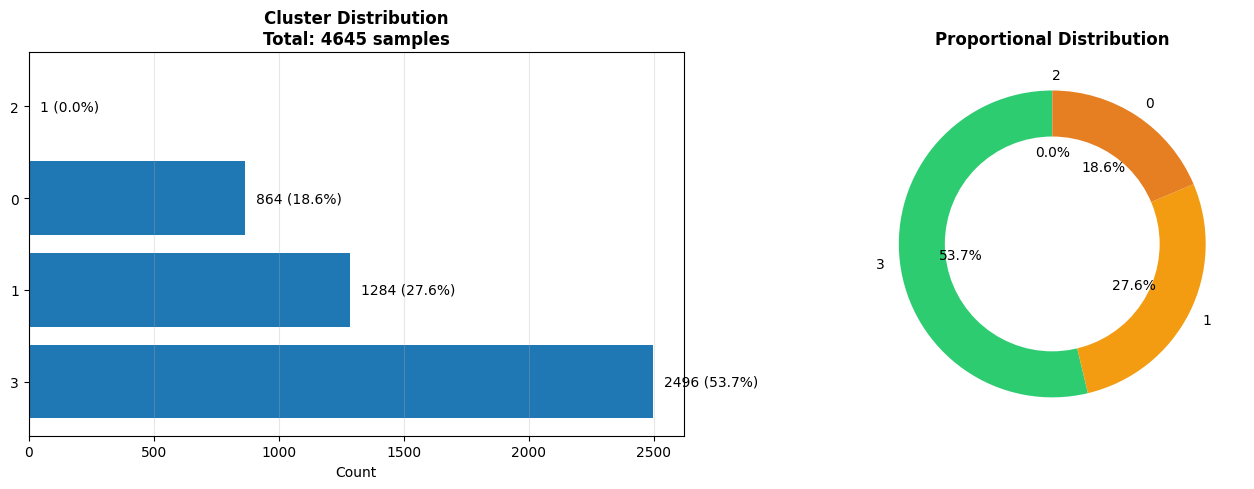


📊 Cluster Distribution Summary:
----------------------------------------
              3:  2496 ( 53.7%)
              1:  1284 ( 27.6%)
              0:   864 ( 18.6%)
              2:     1 (  0.0%)

⚠️ Warning: Largest cluster represents 53.7% of data - possible imbalance!


In [88]:
def plot_cluster_distribution(df, cluster_col='Cluster_Label'):
    """Comprehensive cluster distribution visualization"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Horizontal bar chart with percentages
    ax1 = axes[0]
    cluster_order = df[cluster_col].value_counts().index
    total = len(df)
    
    bars = ax1.barh(range(len(cluster_order)), df[cluster_col].value_counts()[cluster_order])
    ax1.set_yticks(range(len(cluster_order)))
    ax1.set_yticklabels(cluster_order)
    
    for i, (bar, cluster) in enumerate(zip(bars, cluster_order)):
        count = bar.get_width()
        pct = 100 * count / total
        ax1.text(count + total*0.01, bar.get_y() + bar.get_height()/2, 
                f'{count} ({pct:.1f}%)', va='center', fontsize=10)
    
    ax1.set_xlabel('Count')
    ax1.set_title(f'{cluster_col} Distribution\nTotal: {total} samples', fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Donut chart
    ax2 = axes[1]
    colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
    wedges, texts, autotexts = ax2.pie(df[cluster_col].value_counts(), 
                                        labels=cluster_order, 
                                        autopct='%1.1f%%',
                                        colors=colors[:len(cluster_order)],
                                        startangle=90)
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax2.add_artist(centre_circle)
    ax2.set_title('Proportional Distribution', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n📊 Cluster Distribution Summary:")
    print("-" * 40)
    for cluster in cluster_order:
        count = df[cluster_col].value_counts()[cluster]
        pct = 100 * count / total
        print(f"{cluster:15}: {count:5} ({pct:5.1f}%)")
    
    # Check for severe imbalance
    max_pct = df[cluster_col].value_counts(normalize=True).max()
    if max_pct > 0.5:
        print(f"\n⚠️ Warning: Largest cluster represents {max_pct:.1%} of data - possible imbalance!")

# Use the function
plot_cluster_distribution(df, 'Cluster')

In [89]:
cluster_names = {
    0: "Low Risk Group",
    1: "Moderate",
    2: "Risky",
    3: "High Risk"
}

df['Cluster_Label'] = df['Cluster'].map(cluster_names)

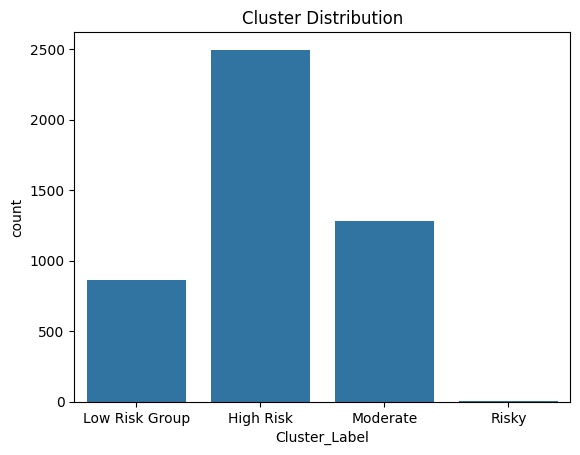

In [90]:
sns.countplot(x="Cluster_Label", data=df)
plt.title("Cluster Distribution")
plt.show()

Cluster Analysis

In [91]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

cluster_analysis = df.groupby('Cluster')[numeric_cols].mean()

print(cluster_analysis)

         PRINCIPALAMT     BALAMT  TERM_Extend    INTRATE  AcrIntAmt  \
Cluster                                                               
0            8.713179   8.212288    59.325231  16.923333   5.096049   
1            7.741308   7.141621    31.447819  17.946355   2.850373   
2           10.915107  10.221978    60.000000  11.400000   3.975186   
3            7.654323   6.478465    30.746394  17.987115   2.577901   

         LoanAge_Current  LOANCYCLE  Principal_Fequency   OrigTerm  \
Cluster                                                              
0             254.396991   4.616898            1.712963  57.608796   
1              52.222741   3.947040            1.003894  31.483645   
2               0.000000   1.000000            6.000000  60.000000   
3             109.592147   4.082532            1.014824  30.854567   

         GracePeriod  ...  Restructure_N  Restructure_Y  \
Cluster               ...                                 
0           1.353009  ...       0.

In [92]:
print(df['Cluster'].value_counts())

Cluster
3    2496
1    1284
0     864
2       1
Name: count, dtype: int64


Add readable cluster profile

In [93]:
cluster_profile = cluster_analysis.T
print(cluster_profile)

Cluster                             0          1          2           3
PRINCIPALAMT                 8.713179   7.741308  10.915107    7.654323
BALAMT                       8.212288   7.141621  10.221978    6.478465
TERM_Extend                 59.325231  31.447819  60.000000   30.746394
INTRATE                     16.923333  17.946355  11.400000   17.987115
AcrIntAmt                    5.096049   2.850373   3.975186    2.577901
LoanAge_Current            254.396991  52.222741   0.000000  109.592147
LOANCYCLE                    4.616898   3.947040   1.000000    4.082532
Principal_Fequency           1.712963   1.003894   6.000000    1.014824
OrigTerm                    57.608796  31.483645  60.000000   30.854567
GracePeriod                  1.353009   0.027259   0.000000    0.009615
NumInstPaid                 20.447917  12.140187  33.000000   17.300080
NumInstNotPaid               8.259259   1.605919   0.000000    2.906651
NumInstNotDue               35.509259  18.141745  27.000000   10

Visualization

⚠️ 60 features detected. Showing top 15 most varying features.


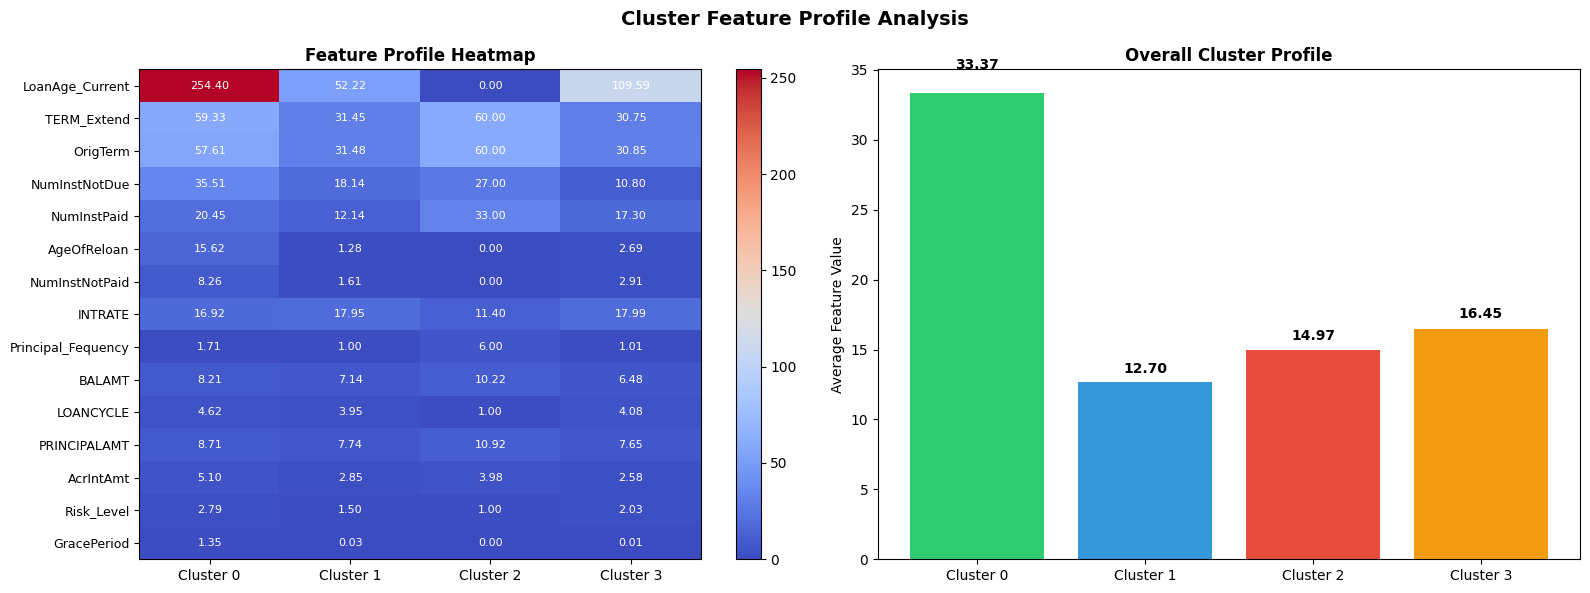


📊 Key Differentiating Features:
  • LoanAge_Current: range = 254.397
  • TERM_Extend: range = 29.254
  • OrigTerm: range = 29.145
  • NumInstNotDue: range = 24.706
  • NumInstPaid: range = 20.860


In [94]:
def plot_cluster_profiles(cluster_analysis, top_n=15):
    """Smart cluster profile visualization"""
    
    # Determine if we have too many features
    n_features = len(cluster_analysis.columns)
    
    if n_features > 20:
        print(f"⚠️ {n_features} features detected. Showing top {top_n} most varying features.")
        # Show only top varying features
        feature_variance = cluster_analysis.var(axis=0).sort_values(ascending=False)
        cluster_analysis = cluster_analysis[feature_variance.head(top_n).index]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(6, len(cluster_analysis.columns) * 0.3)))
    
    # Heatmap (transposed for readability)
    im = ax1.imshow(cluster_analysis.T, cmap='coolwarm', aspect='auto')
    ax1.set_xticks(range(len(cluster_analysis)))
    ax1.set_xticklabels([f'Cluster {i}' for i in cluster_analysis.index])
    ax1.set_yticks(range(len(cluster_analysis.columns)))
    ax1.set_yticklabels(cluster_analysis.columns, fontsize=9)
    ax1.set_title('Feature Profile Heatmap', fontweight='bold')
    plt.colorbar(im, ax=ax1)
    
    # Add annotations
    for i in range(len(cluster_analysis.columns)):
        for j in range(len(cluster_analysis)):
            text = ax1.text(j, i, f'{cluster_analysis.iloc[j, i]:.2f}',
                          ha="center", va="center", color="white", fontsize=8)
    
    # Bar chart for cluster differences
    cluster_means = cluster_analysis.mean(axis=1)
    ax2.bar(range(len(cluster_means)), cluster_means, 
            color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'][:len(cluster_means)])
    ax2.set_xticks(range(len(cluster_means)))
    ax2.set_xticklabels([f'Cluster {i}' for i in cluster_means.index])
    ax2.set_ylabel('Average Feature Value')
    ax2.set_title('Overall Cluster Profile', fontweight='bold')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    for i, v in enumerate(cluster_means):
        ax2.text(i, v + 0.05 * abs(v), f'{v:.2f}', ha='center', fontweight='bold')
    
    plt.suptitle('Cluster Feature Profile Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n📊 Key Differentiating Features:")
    feature_diff = cluster_analysis.max() - cluster_analysis.min()
    top_diff = feature_diff.sort_values(ascending=False).head(5)
    for feat, diff in top_diff.items():
        print(f"  • {feat}: range = {diff:.3f}")

# Use it
plot_cluster_profiles(cluster_analysis, top_n=15)

## MODELING



UNSUPERVISED LEARNING

K-Means Clustering

In [95]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_model['Cluster'] = kmeans.fit_predict(X_scaled)

Cluster Analysis (FIX ERROR HERE)

In [96]:
cluster_analysis = df_model.groupby('Cluster').mean(numeric_only=True)
print(cluster_analysis)

         PRINCIPALAMT     BALAMT  TERM_Extend    INTRATE  AcrIntAmt  \
Cluster                                                               
0            8.713179   8.212288    59.325231  16.923333   5.096049   
1            7.741308   7.141621    31.447819  17.946355   2.850373   
2           10.915107  10.221978    60.000000  11.400000   3.975186   
3            7.654323   6.478465    30.746394  17.987115   2.577901   

         LoanAge_Current  LOANCYCLE  Principal_Fequency   OrigTerm  \
Cluster                                                              
0             254.396991   4.616898            1.712963  57.608796   
1              52.222741   3.947040            1.003894  31.483645   
2               0.000000   1.000000            6.000000  60.000000   
3             109.592147   4.082532            1.014824  30.854567   

         GracePeriod  ...  Restructure_N  Restructure_Y  \
Cluster               ...                                 
0           1.353009  ...       0.

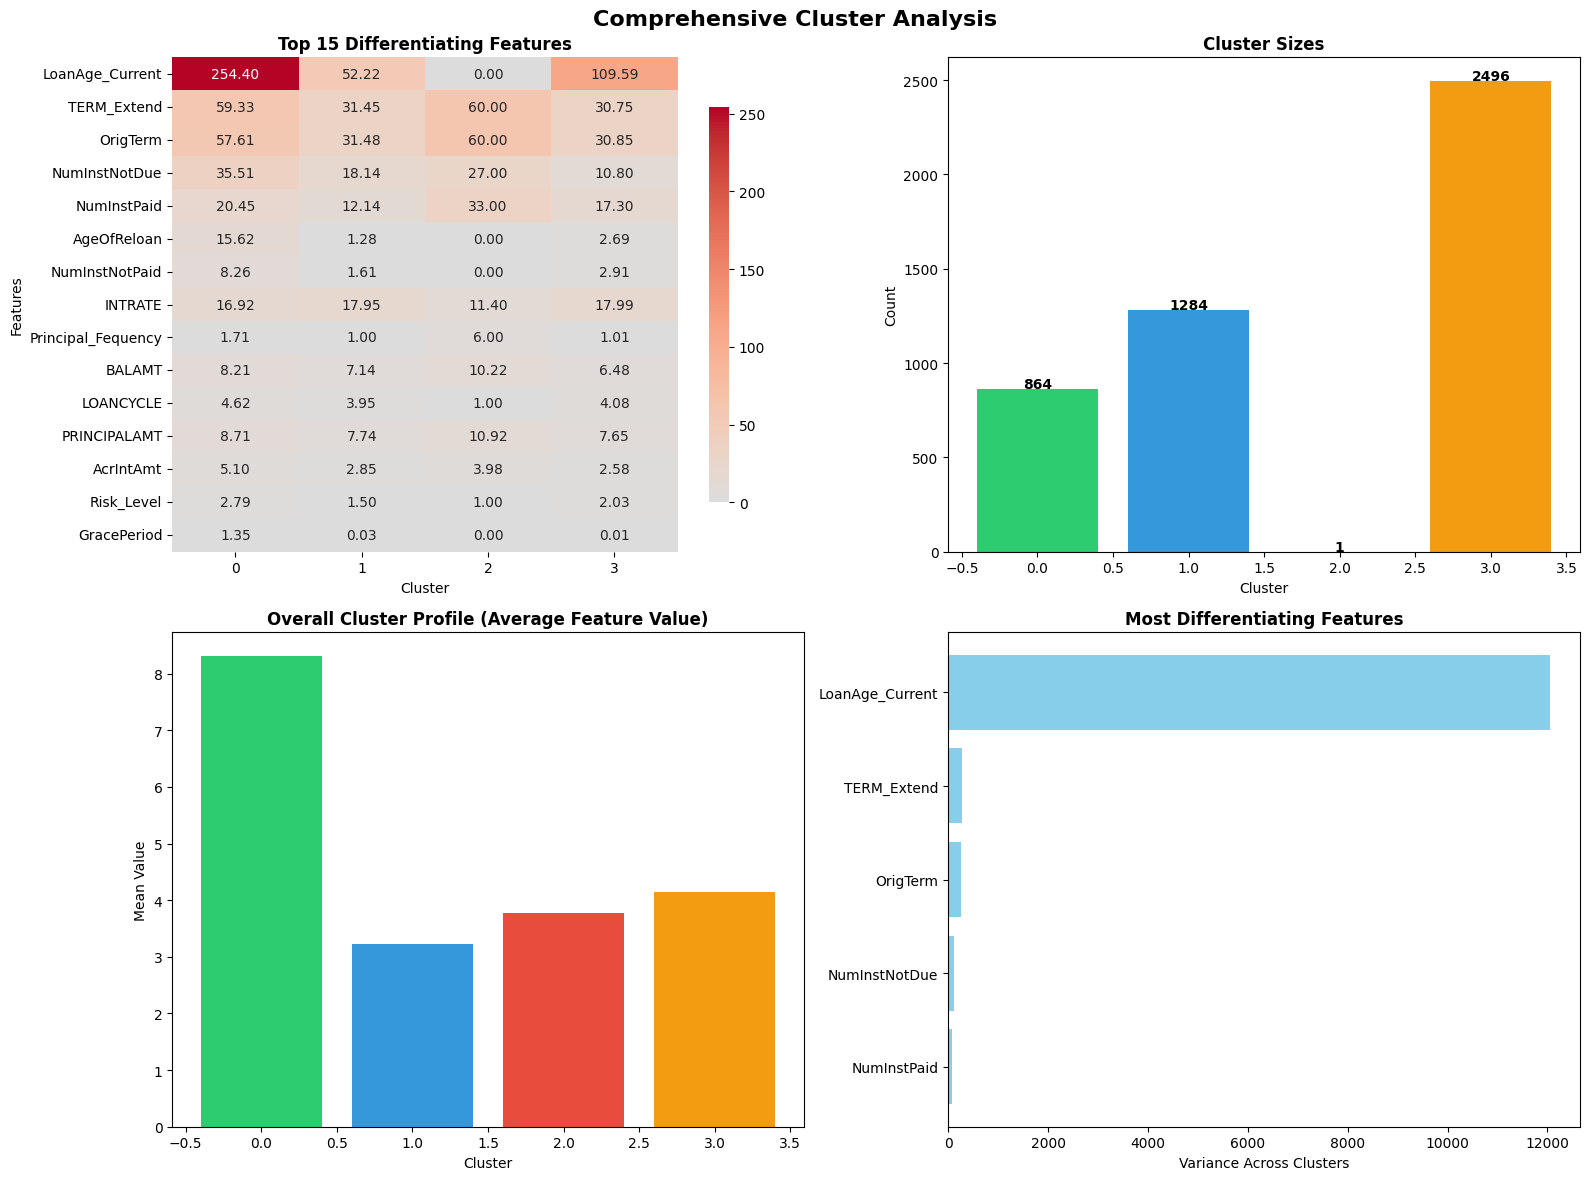


CLUSTER INSIGHTS SUMMARY

🔵 CLUSTER 0 (n=864, 18.6%)
   ↑ HIGHER: LoanAge_Current(254.40), TERM_Extend(59.33), OrigTerm(57.61)
   ↓ LOWER: PrType_CEL(0.00), PrType_DPL(0.00), PrType_ECL(0.00)

🔵 CLUSTER 1 (n=1284, 27.6%)
   ↑ HIGHER: AccountType_I(1.00), PAYMENT_MODE_Amortization(0.98), PrType_HIL(0.48)
   ↓ LOWER: PrType_COL(0.00), PrType_ENL(0.00), PrType_CHL(0.00)

🔵 CLUSTER 2 (n=1, 0.0%)
   ↑ HIGHER: TERM_Extend(60.00), OrigTerm(60.00), NumInstPaid(33.00)
   ↓ LOWER: PrType_HIL(0.00), PrType_MTL(0.00), PrType_PWD(0.00)

🔵 CLUSTER 3 (n=2496, 53.7%)
   ↑ HIGHER: AccountType_I(1.00), PAYMENT_MODE_Declining(0.99), Sector_Trade and Commerce(0.53)
   ↓ LOWER: PrType_PWI(0.00), PrType_ECL(0.00), AccountType_G(0.00)


In [97]:
def comprehensive_cluster_analysis(cluster_analysis, df_model):
    """Complete cluster analysis with multiple visualizations"""
    
    # 1. Find most distinguishing features
    feature_variance = cluster_analysis.var(axis=0).sort_values(ascending=False)
    
    # 2. Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # Subplot 1: Heatmap of top features
    ax1 = plt.subplot(2, 2, 1)
    top_features = feature_variance.head(15).index
    sns.heatmap(cluster_analysis[top_features].T, 
                annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=ax1, cbar_kws={"shrink": 0.8})
    ax1.set_title('Top 15 Differentiating Features', fontweight='bold')
    ax1.set_xlabel('Cluster')
    ax1.set_ylabel('Features')
    
    # Subplot 2: Cluster sizes
    ax2 = plt.subplot(2, 2, 2)
    cluster_sizes = df_model['Cluster'].value_counts().sort_index()
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
    bars = ax2.bar(cluster_sizes.index, cluster_sizes.values, color=colors[:len(cluster_sizes)])
    ax2.set_title('Cluster Sizes', fontweight='bold')
    ax2.set_xlabel('Cluster')
    ax2.set_ylabel('Count')
    for bar, size in zip(bars, cluster_sizes.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(size), ha='center', fontweight='bold')
    
    # Subplot 3: Overall profile
    ax3 = plt.subplot(2, 2, 3)
    cluster_means = cluster_analysis.mean(axis=1)
    ax3.bar(cluster_means.index, cluster_means.values, color=colors[:len(cluster_means)])
    ax3.set_title('Overall Cluster Profile (Average Feature Value)', fontweight='bold')
    ax3.set_xlabel('Cluster')
    ax3.set_ylabel('Mean Value')
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Subplot 4: Feature importance summary
    ax4 = plt.subplot(2, 2, 4)
    top_5_features = feature_variance.head(5)
    ax4.barh(range(len(top_5_features)), top_5_features.values, color='skyblue')
    ax4.set_yticks(range(len(top_5_features)))
    ax4.set_yticklabels(top_5_features.index)
    ax4.set_title('Most Differentiating Features', fontweight='bold')
    ax4.set_xlabel('Variance Across Clusters')
    ax4.invert_yaxis()
    
    plt.suptitle('Comprehensive Cluster Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    print("\n" + "="*80)
    print("CLUSTER INSIGHTS SUMMARY")
    print("="*80)
    
    for cluster in cluster_analysis.index:
        print(f"\n🔵 CLUSTER {cluster} (n={cluster_sizes[cluster]}, {100*cluster_sizes[cluster]/len(df_model):.1f}%)")
        
        # Find defining characteristics
        cluster_profile = cluster_analysis.loc[cluster]
        avg_profile = cluster_analysis.mean()
        
        # Features significantly higher than average
        higher = cluster_profile[cluster_profile > avg_profile * 1.2].sort_values(ascending=False)
        if len(higher) > 0:
            print(f"   ↑ HIGHER: {', '.join([f'{feat}({val:.2f})' for feat, val in higher.head(3).items()])}")
        
        # Features significantly lower than average
        lower = cluster_profile[cluster_profile < avg_profile * 0.8].sort_values()
        if len(lower) > 0:
            print(f"   ↓ LOWER: {', '.join([f'{feat}({val:.2f})' for feat, val in lower.head(3).items()])}")

# Run the comprehensive analysis
comprehensive_cluster_analysis(cluster_analysis, df_model)

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [100]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

In [101]:
def evaluate_model(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)

    # Ensure binary confusion matrix
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        return None  # skip if not binary

    return {
        "Model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [102]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res = evaluate_model(y_test, y_pred, name)
    if res:
        results.append(res)

results_df = pd.DataFrame(results)
print(results_df)

Empty DataFrame
Columns: []
Index: []


In [103]:
from sklearn.metrics import classification_report

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           1       0.97      1.00      0.98       859
           2       0.88      0.38      0.53        58
           3       0.72      0.79      0.75        61
           4       0.98      0.99      0.98       416

    accuracy                           0.96      1394
   macro avg       0.89      0.79      0.81      1394
weighted avg       0.96      0.96      0.95      1394


SVM
              precision    recall  f1-score   support

           1       0.90      0.99      0.94       859
           2       0.50      0.02      0.03        58
           3       1.00      0.05      0.09        61
           4       0.92      0.98      0.95       416

    accuracy                           0.91      1394
   macro avg       0.83      0.51      0.50      1394
weighted avg       0.89      0.91      0.87      1394


Decision Tree
              precision    recall  f1-score   support

           1       1.00      1.00 

Fix Isolation Forest with Better Parameters

Optimized Isolation Forest Results:
              precision    recall  f1-score   support

           0       0.69      0.96      0.80      3056
           1       0.70      0.16      0.26      1589

    accuracy                           0.69      4645
   macro avg       0.70      0.56      0.53      4645
weighted avg       0.69      0.69      0.62      4645



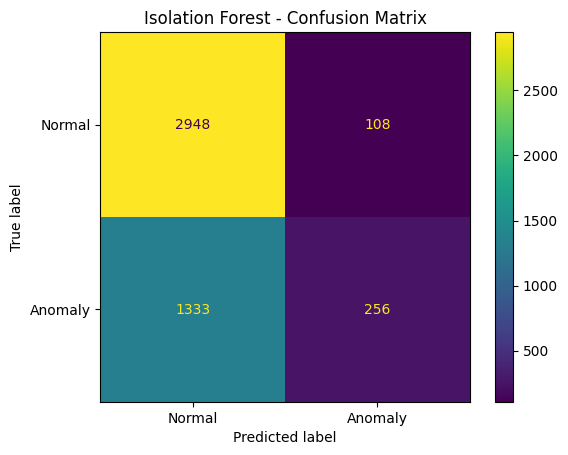

In [104]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Better parameter tuning for Isolation Forest
iso_optimized = IsolationForest(
    contamination='auto',  # Let model estimate contamination
    random_state=42,
    n_estimators=200,      # More trees for stability
    max_samples='auto',
    bootstrap=True,        # Use bootstrap sampling
    verbose=0
)

df['Anomaly_IF_optimized'] = iso_optimized.fit_predict(X_scaled)
df['Anomaly_IF_optimized'] = df['Anomaly_IF_optimized'].map({1: 0, -1: 1})

print("Optimized Isolation Forest Results:")
print(classification_report(df['Risk_Binary'], df['Anomaly_IF_optimized']))

# Confusion matrix
cm = confusion_matrix(df['Risk_Binary'], df['Anomaly_IF_optimized'])
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly']).plot()
plt.title("Isolation Forest - Confusion Matrix")
plt.show()

In [105]:
# Check if target variable is in features
if 'Risk_Binary' in X.columns:
    print("❌ DATA LEAKAGE DETECTED: 'Risk_Binary' found in features!")
    print("Remove target variable from features immediately")
    X = X.drop('Risk_Binary', axis=1)

# Also check for any risk-related columns that might encode the target
risk_columns = [col for col in X.columns if 'risk' in col.lower() or 'anomaly' in col.lower()]
if risk_columns:
    print(f"⚠️ Potential risk-related features: {risk_columns}")
    print("Review these carefully for possible leakage")

❌ DATA LEAKAGE DETECTED: 'Risk_Binary' found in features!
Remove target variable from features immediately


In [106]:
# Remove the target variable from features
if 'Risk_Binary' in X.columns:
    X = X.drop('Risk_Binary', axis=1)
    print("✅ Removed 'Risk_Binary' from features")

# Also check for any other risk-related columns that shouldn't be features
risk_related_cols = ['Risk Level', 'Anomaly_IF', 'Anomaly_AE', 'Cluster']
for col in risk_related_cols:
    if col in X.columns:
        print(f"⚠️ Also consider removing '{col}' if it's derived from or correlates with target")
        # Uncomment if you're sure they should be removed:
        # X = X.drop(col, axis=1)

Features shape: (4645, 62)
Target shape: (4645,)

Target distribution:
Risk_Binary
0    0.657912
1    0.342088
Name: proportion, dtype: float64

ENCODING CATEGORICAL VARIABLES
Categorical columns found (1): ['Cluster_Label']...
Numeric columns found (61): ['PRINCIPALAMT', 'BALAMT', 'TERM_Extend', 'INTRATE', 'AcrIntAmt', 'LoanAge_Current', 'LOANCYCLE', 'Principal_Fequency', 'OrigTerm', 'GracePeriod']...
  Encoded 'Cluster_Label'

Encoded features shape: (4645, 62)

CORRECTED RANDOM FOREST RESULTS
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       611
        Risk       1.00      1.00      1.00       318

    accuracy                           1.00       929
   macro avg       1.00      1.00      1.00       929
weighted avg       1.00      1.00      1.00       929



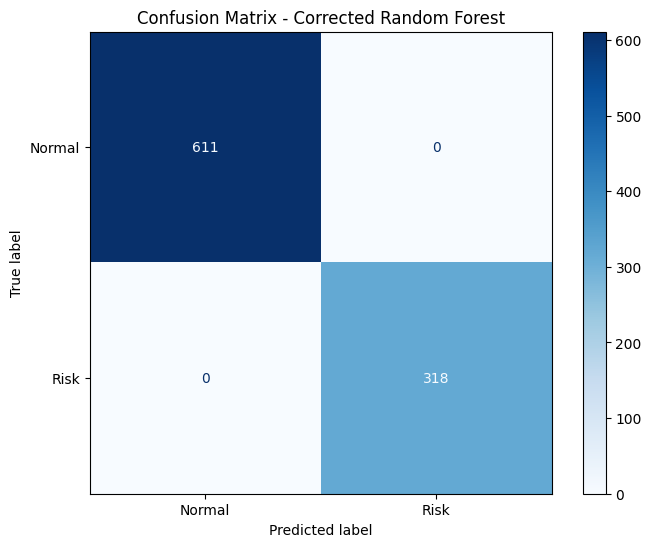

In [107]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare data (NO LEAKAGE)
y = df['Risk_Binary']  # Target

# Make sure y is numeric
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print(f"Encoded target: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Features without target
X = df.drop(['Risk_Binary'], axis=1)

# Remove potential leakage columns
columns_to_remove = ['Anomaly_IF', 'Anomaly_AE', 'Cluster']
X = X.drop([col for col in columns_to_remove if col in X.columns], axis=1, errors='ignore')

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{pd.Series(y).value_counts(normalize=True)}")

# 2. Handle categorical variables
print("\n" + "="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

# Find categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns found ({len(categorical_cols)}): {categorical_cols[:10]}...")
print(f"Numeric columns found ({len(numeric_cols)}): {numeric_cols[:10]}...")

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    # Handle any NaN values if present
    X_encoded[col] = X_encoded[col].astype(str)
    X_encoded[col] = le.fit_transform(X_encoded[col])
    print(f"  Encoded '{col}'")

# Alternative: Use One-Hot Encoding for categorical with few categories
# from sklearn.preprocessing import OneHotEncoder
# X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nEncoded features shape: {X_encoded.shape}")

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# 4. Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# 5. Predict and evaluate
y_pred = rf.predict(X_test)

print("\n" + "="*60)
print("CORRECTED RANDOM FOREST RESULTS")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Risk']))

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Risk'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Corrected Random Forest')
plt.show()

In [108]:
# Check correlations with target
correlations = X_encoded.corrwith(y).abs().sort_values(ascending=False)

print("="*60)
print("TOP CORRELATIONS WITH TARGET (Potential Leakage)")
print("="*60)
print(correlations.head(20))

# Look for any column with near-perfect correlation (>0.99)
high_corr = correlations[correlations > 0.99]
if len(high_corr) > 0:
    print("\n❌ EXTREME CORRELATION DETECTED - DATA LEAKAGE!")
    print(high_corr)

TOP CORRELATIONS WITH TARGET (Potential Leakage)
Risk_Level                   0.979045
LoanAge_Current              0.763885
NumInstNotPaid               0.729805
AcrIntAmt                    0.556768
AgeOfReloan                  0.224957
Anomaly_IF_optimized         0.222015
PAYMENT_MODE_Amortization    0.206397
PAYMENT_MODE_Balloon         0.189841
GracePeriod                  0.185503
Sector_Trade and Commerce    0.171981
TERM_Extend                  0.167502
OrigTerm                     0.161366
PrType_ENL                   0.157416
Sector_Household/Family      0.143421
Reloan_No                    0.139268
NumInstNotDue                0.130902
PrType_ASL                   0.129438
Cluster_Label                0.120293
PrType_BIL                   0.111779
PrType_MQL                   0.105861
dtype: float64


In [109]:
from sklearn.ensemble import IsolationForest

# Train model
iso = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly_IF'] = iso.fit_predict(X_scaled)

# Convert to binary (IMPORTANT)
df['Anomaly_IF'] = df['Anomaly_IF'].map({1: 0, -1: 1})

In [110]:
from sklearn.metrics import classification_report

print(classification_report(df['Risk_Binary'], df['Anomaly_IF']))

              precision    recall  f1-score   support

           0       0.68      0.98      0.80      3056
           1       0.70      0.10      0.18      1589

    accuracy                           0.68      4645
   macro avg       0.69      0.54      0.49      4645
weighted avg       0.68      0.68      0.59      4645



In [111]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_dim=X_scaled.shape[1]),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(X_scaled.shape[1], activation='sigmoid')
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_scaled, X_scaled, epochs=20, batch_size=32, validation_split=0.2)

c:\Users\WINDOWS 11\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0788 - val_loss: 0.8461
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8946 - val_loss: 0.7366
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7735 - val_loss: 0.6986
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8238 - val_loss: 0.6833
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8570 - val_loss: 0.6785
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7914 - val_loss: 0.6743
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6726 - val_loss: 0.6723
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6844 - val_loss: 0.6714
Epoch 9/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7243 - val_loss: 0.6705
Epoch 10/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6509 - val_loss: 0.6687
Epoch 11/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9091 - val_loss: 0.6673
Epoch 12/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [112]:
recon = model.predict(X_scaled)
loss = np.mean((X_scaled - recon)**2, axis=1)

threshold = np.percentile(loss, 95)
df['Anomaly_AE'] = (loss > threshold).astype(int)

print(confusion_matrix(y, df['Anomaly_AE']))

146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[2914  142]
 [1498   91]]


Epoch 1/50


c:\Users\WINDOWS 11\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9141 - val_loss: 0.6813
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6179 - val_loss: 0.5421
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5670 - val_loss: 0.4649
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4496 - val_loss: 0.4112
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3703 - val_loss: 0.3950
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4344 - val_loss: 0.3709
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3693 - val_loss: 0.3508
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2825 - val_loss: 0.3422
Epoch 9/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3555 - val_loss: 0.3316
Epoch 10/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2492 - val_loss: 0.3220
Epoch 11/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2584 - val_loss: 0.3118
Epoch 12/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.

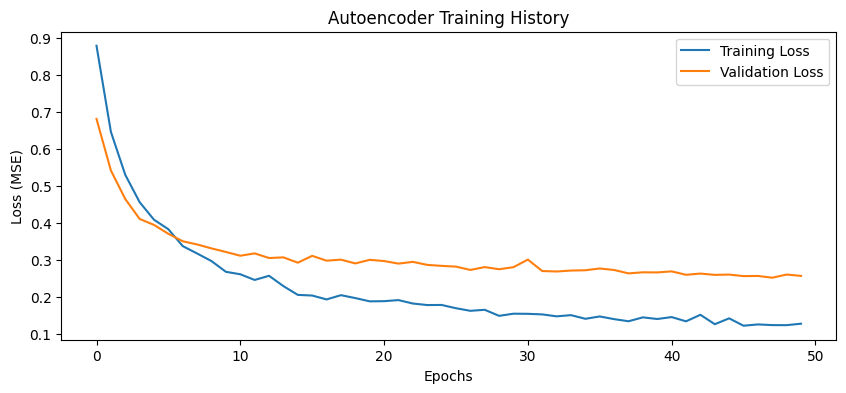

In [113]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Assuming X_scaled is your scaled features
# Make sure you have your true labels (assuming 'Cluster' or similar as target)
# If not, you need to define your anomaly ground truth

# Define autoencoder with better architecture
input_dim = X_scaled.shape[1]

autoencoder = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),  # Bottleneck
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(input_dim, activation='linear')  # Use linear for reconstruction
])

autoencoder.compile(optimizer='adam', loss='mse')

# Add early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Autoencoder Training History')
plt.legend()
plt.show()

146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


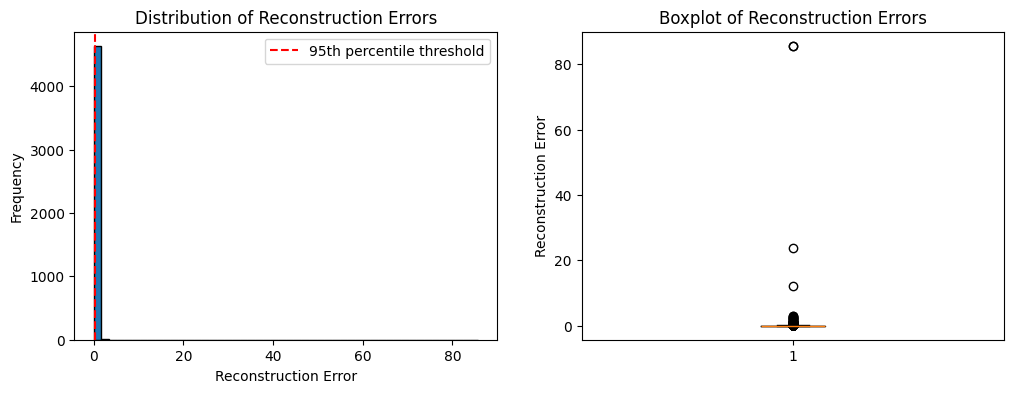

Threshold (95th percentile): 0.2291
Threshold (MAD method): 5.5024


In [114]:
# Get reconstructions
reconstructions = autoencoder.predict(X_scaled)

# Calculate reconstruction error per sample
reconstruction_errors = np.mean((X_scaled - reconstructions) ** 2, axis=1)

# Visualize error distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(reconstruction_errors, bins=50, edgecolor='black')
plt.axvline(np.percentile(reconstruction_errors, 95), color='red', linestyle='--', label='95th percentile threshold')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Errors')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(reconstruction_errors)
plt.ylabel('Reconstruction Error')
plt.title('Boxplot of Reconstruction Errors')
plt.show()

# Determine threshold (multiple methods)
threshold_percentile = np.percentile(reconstruction_errors, 95)
threshold_mad = np.median(reconstruction_errors) + 3 * np.std(reconstruction_errors)

print(f"Threshold (95th percentile): {threshold_percentile:.4f}")
print(f"Threshold (MAD method): {threshold_mad:.4f}")

# Choose threshold
threshold = threshold_percentile

In [115]:
# If you have actual anomaly labels (y_true), use them
# Otherwise, you can define anomalies based on your cluster labels

# Option 1: If you have 'Cluster' column from KMeans
if 'Cluster' in df.columns:
    # Define risky clusters as anomalies (adjust based on your clusters)
    # Example: Cluster with high risk = anomaly
    risky_clusters = [1, 3]  # Adjust based on your cluster analysis
    y_true = df['Cluster'].isin(risky_clusters).astype(int)
    print("Using Cluster labels as ground truth")
    
# Option 2: If you have a specific anomaly column
elif 'Anomaly' in df.columns:
    y_true = df['Anomaly']
    print("Using existing Anomaly column")

# Option 3: Define based on business rules
else:
    # Example: Define anomalies based on high risk indicators
    high_risk_conditions = (
        (df['Risk Level'] > 0.8) |  # High risk score
        (df['GRACE_PERIOD'] > 30) |  # Long grace period
        (df['RESTRUCTURE_Y'] == 1)   # Restructured loans
    )
    y_true = high_risk_conditions.astype(int)
    print("Created anomaly labels based on business rules")

Using Cluster labels as ground truth


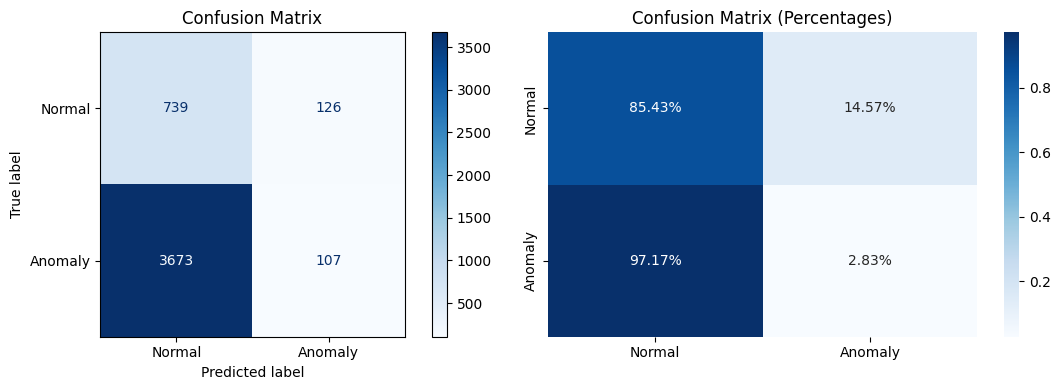


ANOMALY DETECTION RESULTS

Threshold used: 0.2291
Anomalies detected: 233 (5.0%)
True anomalies: 3780 (81.4%)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.17      0.85      0.28       865
     Anomaly       0.46      0.03      0.05      3780

    accuracy                           0.18      4645
   macro avg       0.31      0.44      0.17      4645
weighted avg       0.40      0.18      0.10      4645



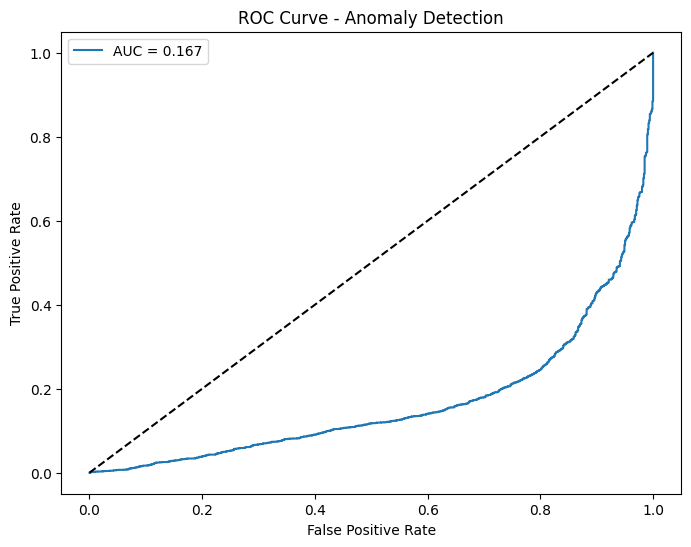

In [116]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Get predictions
y_pred = (reconstruction_errors > threshold).astype(int)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot as table
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix')

# Plot as percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_percentage, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Normal', 'Anomaly'], 
            yticklabels=['Normal', 'Anomaly'], ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages)')
2
plt.tight_layout()
plt.show()

# Print detailed metrics
print("\n" + "="*60)
print("ANOMALY DETECTION RESULTS")
print("="*60)
print(f"\nThreshold used: {threshold:.4f}")
print(f"Anomalies detected: {y_pred.sum()} ({100*y_pred.sum()/len(y_pred):.1f}%)")
print(f"True anomalies: {y_true.sum()} ({100*y_true.sum()/len(y_true):.1f}%)")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

# Additional metrics
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_true, reconstruction_errors)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Anomaly Detection')
plt.legend()
plt.show()